In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
import copy
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import pickle
import sys

# Load

In [2]:
path = "D:\\Research"

In [3]:
artnet_2024 = pd.read_excel(f"{path}\\Creativity_Artnet\\Datasets\\ArtNet\\Artnet_Europe_2024_merged.xlsx")

In [4]:
artnet_2024_embed = np.load(f"{path}\\Creativity_Artnet\\Datasets\\Dinov2_embedding_2024.npy",allow_pickle=True)

In [5]:
year_to_prior = {}
current_prior = set()
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Start Building Prior Knowledge")
for year in sorted(artnet_2024["workyear from"].unique()):
    year_rows_index = artnet_2024[artnet_2024["workyear from"] == year].index
    year_to_prior[year] = copy.deepcopy(current_prior)  # store snapshot before update
    current_prior |= set(year_rows_index)
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Finish Building Prior Knowledge")

2026-01-02 06:32:37: Start Building Prior Knowledge
2026-01-02 06:32:51: Finish Building Prior Knowledge


In [15]:
BASELINE_YEAR=1600

In [19]:
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Start Building Prior Model")
gmms=[]
for year in sorted(artnet_2024["workyear from"].unique()):
    if year < BASELINE_YEAR:
        continue
    prior_knowledge = artnet_2024_embed_reduced[list(year_to_prior.get(year, set()))]
    gmm = GaussianMixture(n_components=10, covariance_type='diag',reg_covar=1e-3) # 20 is a good amount of components
    gmm.fit(prior_knowledge)
    gmms.append(gmm)
    with open(f"Dinov2_gmm_{year}.pkl", "wb") as f:
        pickle.dump(gmm, f)
    if year%25 ==0:
        print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Currently at year {year}")
        
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Finish Building Prior Model")

2026-01-02 07:13:35: Start Building Prior Model
2026-01-02 07:13:35: Currently at year 1600
2026-01-02 07:13:37: Currently at year 1625
2026-01-02 07:13:41: Currently at year 1650
2026-01-02 07:13:46: Currently at year 1675
2026-01-02 07:13:50: Currently at year 1700
2026-01-02 07:13:53: Currently at year 1725
2026-01-02 07:13:59: Currently at year 1750
2026-01-02 07:14:09: Currently at year 1775
2026-01-02 07:14:20: Currently at year 1800
2026-01-02 07:14:31: Currently at year 1825
2026-01-02 07:14:41: Currently at year 1850
2026-01-02 07:14:52: Currently at year 1875
2026-01-02 07:15:07: Currently at year 1900
2026-01-02 07:15:52: Currently at year 1925
2026-01-02 07:17:00: Currently at year 1950
2026-01-02 07:19:34: Currently at year 1975
2026-01-02 07:21:28: Currently at year 2000
2026-01-02 07:23:00: Finish Building Prior Model


In [20]:
gmms_by_year={}
count=0
for year in sorted(artnet_2024["workyear from"].unique()):
    if year < BASELINE_YEAR:
        continue
    prior_knowledge = artnet_2024_embed_reduced[list(year_to_prior.get(year, set()))]
    gmm = gmms[count]
    count+=1
    gmms_by_year[year] = gmm
    if year%25 ==0:
        print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Currently at year {year}")

2026-01-02 07:23:00: Currently at year 1600
2026-01-02 07:23:00: Currently at year 1625
2026-01-02 07:23:00: Currently at year 1650
2026-01-02 07:23:00: Currently at year 1675
2026-01-02 07:23:00: Currently at year 1700
2026-01-02 07:23:00: Currently at year 1725
2026-01-02 07:23:00: Currently at year 1750
2026-01-02 07:23:00: Currently at year 1775
2026-01-02 07:23:00: Currently at year 1800
2026-01-02 07:23:00: Currently at year 1825
2026-01-02 07:23:00: Currently at year 1850
2026-01-02 07:23:00: Currently at year 1875
2026-01-02 07:23:00: Currently at year 1900
2026-01-02 07:23:01: Currently at year 1925
2026-01-02 07:23:01: Currently at year 1950
2026-01-02 07:23:02: Currently at year 1975
2026-01-02 07:23:03: Currently at year 2000


In [21]:
with open(f"Dinov2_gmm_dict.pkl", "wb") as f:
    pickle.dump(gmms_by_year, f)

In [22]:
sys.getsizeof(gmms_by_year)

18512

In [23]:
def pointwise_surprise(x, gmm_P):
    x = x.reshape(1, -1) 
    log_prob = gmm_P.score(x)
    return -log_prob  # higher means more surprising

In [24]:
def compute_surprise(i,year, gmms_by_year,embedding,BASELINE_YEAR):
    if year <= BASELINE_YEAR:  # pre-year baseline
        return i, 0
    # print(f"The total steps are: {playcount}")
    # mark new pairs not in prior knowledge
    gmm = gmms_by_year[year]
    surprise = pointwise_surprise(embedding,gmm)
    return i, surprise

In [25]:
number_size = 100000
range_start = 0
range_end = min(range_start+number_size,artnet_2024.shape[0])
N = min(number_size, artnet_2024.shape[0]-range_start)
max_workers = 20
BASELINE_YEAR=1600
print(f"{datetime.now():%Y-%m-%d %H:%M:%S}: Start")
while range_start < artnet_2024.shape[0]:
    print(f"{datetime.now():%Y-%m-%d %H:%M:%S}: Now at {range_start}")
    surprise = np.zeros(N)
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(compute_surprise, i, 
                    artnet_2024.iloc[i]["workyear from"],
                    gmms_by_year,
                    artnet_2024_embed_reduced[i],
                    BASELINE_YEAR): i
            for i in range(range_start,range_end)
        }
        completed = 0
        for fut in as_completed(futures):
            i,row_surprise = fut.result()
            surprise[i-range_start]  = row_surprise
            completed += 1
            if completed % 10000 == 0:
                print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Completed {completed}/{artnet_2024.shape[0]}")
    print(f"{datetime.now():%Y-%m-%d %H:%M:%S}: Saving embeddings")
    np.save(f"{path}\\Creativity_Artnet\\Datasets\\Dinov2_Surprise_2024\\surprise_{range_start}.npy", surprise)
    print(f"{datetime.now():%Y-%m-%d %H:%M:%S}: Embedding Saved")
    range_start = range_start + N
    range_end = min(range_start+number_size,artnet_2024.shape[0])
    N = min(number_size, artnet_2024.shape[0]-range_start)
print(f"{datetime.now():%Y-%m-%d %H:%M:%S}: Ends")

2026-01-02 07:23:03: Start
2026-01-02 07:23:03: Now at 0
2026-01-02 07:23:34: Completed 10000/355551
2026-01-02 07:23:34: Completed 20000/355551
2026-01-02 07:23:34: Completed 30000/355551
2026-01-02 07:23:34: Completed 40000/355551
2026-01-02 07:23:34: Completed 50000/355551
2026-01-02 07:23:34: Completed 60000/355551
2026-01-02 07:23:34: Completed 70000/355551
2026-01-02 07:23:34: Completed 80000/355551
2026-01-02 07:23:34: Completed 90000/355551
2026-01-02 07:23:34: Completed 100000/355551
2026-01-02 07:23:34: Saving embeddings
2026-01-02 07:23:34: Embedding Saved
2026-01-02 07:23:34: Now at 100000
2026-01-02 07:24:03: Completed 10000/355551
2026-01-02 07:24:03: Completed 20000/355551
2026-01-02 07:24:03: Completed 30000/355551
2026-01-02 07:24:03: Completed 40000/355551
2026-01-02 07:24:03: Completed 50000/355551
2026-01-02 07:24:03: Completed 60000/355551
2026-01-02 07:24:03: Completed 70000/355551
2026-01-02 07:24:03: Completed 80000/355551
2026-01-02 07:24:03: Completed 90000/35

# Merge

In [26]:
import pickle
import glob

In [27]:
folder_path = f"{path}\\Creativity_Artnet\\Datasets\\Dinov2_Surprise_2024"
npy_files = glob.glob(f"{folder_path}/*.npy")

In [28]:
arrays = [np.load(f, allow_pickle=True) for f in npy_files]
big_array = np.concatenate(arrays, axis=0)
np.save(f"{path}\\Creativity_Artnet\\Datasets\\Dinov2_surprise_2024.npy", big_array)

In [29]:
big_array.shape

(355551,)

In [30]:
surprise_array = np.vstack(big_array)

In [31]:
np.save(f"{path}\\Creativity_Artnet\\Datasets\\Dinov2_surprise_2024.npy", surprise_array)

In [32]:
surprise_array.shape

(355551, 1)

# Test

In [7]:
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: PCA Start")
pca = PCA(n_components=16)  # or 5, based on explained variance
artnet_2024_embed_reduced = pca.fit_transform(artnet_2024_embed)
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: PCA End")

2026-01-02 06:33:30: PCA Start
2026-01-02 06:33:39: PCA End


In [8]:
ks = range(1, 21)
bics = []
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Start")
for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
    gmm.fit(artnet_2024_embed_reduced)
    bics.append(gmm.bic(artnet_2024_embed_reduced))
    print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Currently at {k}")
best_k = ks[np.argmin(bics)]
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: End")

2026-01-02 06:33:46: Start
2026-01-02 06:33:49: Currently at 1
2026-01-02 06:33:51: Currently at 2
2026-01-02 06:34:01: Currently at 3
2026-01-02 06:34:09: Currently at 4
2026-01-02 06:34:19: Currently at 5
2026-01-02 06:34:35: Currently at 6
2026-01-02 06:35:10: Currently at 7
2026-01-02 06:35:52: Currently at 8
2026-01-02 06:36:14: Currently at 9
2026-01-02 06:36:53: Currently at 10
2026-01-02 06:37:32: Currently at 11
2026-01-02 06:38:11: Currently at 12
2026-01-02 06:38:47: Currently at 13
2026-01-02 06:39:44: Currently at 14
2026-01-02 06:40:31: Currently at 15
2026-01-02 06:41:43: Currently at 16
2026-01-02 06:42:33: Currently at 17
2026-01-02 06:43:33: Currently at 18
2026-01-02 06:44:30: Currently at 19
2026-01-02 06:45:31: Currently at 20
2026-01-02 06:45:31: End


In [9]:
ks = range(21, 30)
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Start")
for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
    gmm.fit(artnet_2024_embed_reduced)
    bics.append(gmm.bic(artnet_2024_embed_reduced))
    print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Currently at {k}")

print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: End")

2026-01-02 06:46:55: Start
2026-01-02 06:48:21: Currently at 21
2026-01-02 06:49:28: Currently at 22
2026-01-02 06:50:52: Currently at 23
2026-01-02 06:52:11: Currently at 24
2026-01-02 06:53:28: Currently at 25
2026-01-02 06:54:47: Currently at 26
2026-01-02 06:56:02: Currently at 27
2026-01-02 06:57:24: Currently at 28
2026-01-02 06:58:47: Currently at 29
2026-01-02 06:58:47: End


In [10]:
np.save("Dinov2_gmm_component.npy", bics)

In [14]:
ks = range(1, 30)
best_k = ks[np.argmin(bics)]
print(f"Best k is {best_k}")

Best k is 29


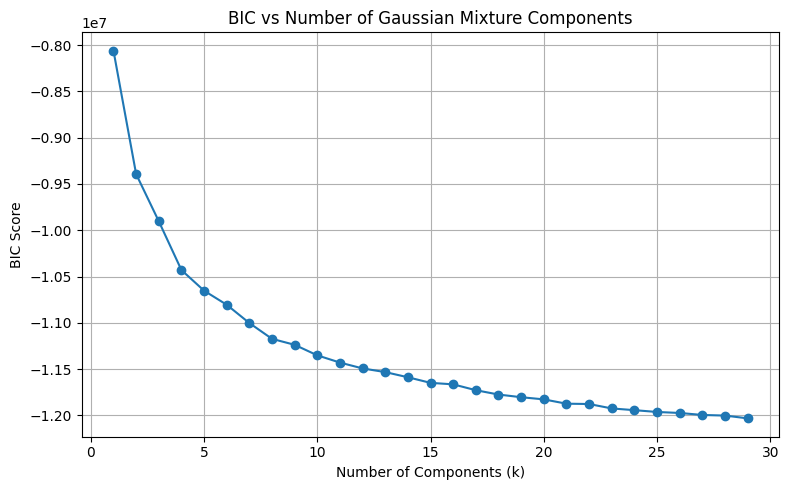

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(list(ks), bics, marker='o')
plt.xlabel("Number of Components (k)")
plt.ylabel("BIC Score")
plt.title("BIC vs Number of Gaussian Mixture Components")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
plt.savefig("Dinov2_bic_vs_k.jpg", dpi=300)

<Figure size 640x480 with 0 Axes>

In [26]:
best_k

20

In [ ]:
for i in range(artnet_2024_embed_reduced.shape[0]):
    row_dict = artnet_2024.iloc[i]
    year = row_dict["workyear from"]
    if year <= BASELINE_YEAR:  # pre-year baseline
        break
        return i, 0
    prior_knowledge = artnet_2024_embed_reduced[list(year_to_prior.get(year, set()))]
    A = embeddings[i]
    gmm = GaussianMixture(n_components=20, covariance_type='diag',reg_covar=1e-3)
    gmm.fit(prior_knowledge)
    print()

In [ ]:
def pointwise_surprise(x, gmm_P):
    x = x.reshape(1, -1) 
    log_prob = gmm_P.score(x)
    return -log_prob  # higher means more surprising

In [ ]:
surprise_raw1 = np.zeros(artnet_2024_embed_reduced.shape[0])
gmms1=[]
for i in range(len(date_list)-2):
    baseline_date=date_list[i+1]
    baseline_indx = np.where(temp_rank['date']<=baseline_date)
    #print(baseline_indx)
    baseline_group = clip_embedding_wikiart_reduced[baseline_indx]
    evaluate_date = date_list[i+2]
    evaluate_indx=np.where(temp_rank['date']==evaluate_date)
    evaluate_group = clip_embedding_wikiart_reduced[evaluate_indx]
    gmm1 = GaussianMixture(n_components=2, covariance_type='diag',reg_covar=1e-3)
    gmm1.fit(baseline_group)
    gmms1.append(gmm1)
    for i in range(len(evaluate_indx[0])):
        surprise_raw1[evaluate_indx[0][i]] = pointwise_surprise(clip_embedding_wikiart_reduced[evaluate_indx[0][i]],gmm1)

In [79]:
i=0
row = artnet_2024.iloc[i]
year = artnet_2024.iloc[i]["workyear from"]

In [58]:

idx, surprise1 = compute_surprise(i, year, gmms_by_year, artnet_2024_embed_reduced[i], BASELINE_YEAR)

In [59]:
surprise

np.float64(-18.749726886993752)

In [60]:
pointwise_surprise(artnet_2024_embed_reduced[i], gmms_by_year[year])

np.float64(-18.749726886993752)

In [85]:
artnet_2024_embed_reduced[i].reshape(1, -1).shape

(1, 16)

In [65]:
gmm = gmms_by_year[year]

In [86]:
log_prob = gmm.predict(artnet_2024_embed_reduced[i].reshape(1, -1))

In [87]:
log_prob

array([17])